In [ ]:
# !pip install U langchain-huggingface lightfm langchain sentence-transformers faiss-cpu langchain_community datasets chromadb ragas

In [1]:

import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# from difflib import SequenceMatcher
from datasets import load_dataset
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.cross_validation import random_train_test_split
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

user_data = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_CDs_and_Vinyl", split="full", trust_remote_code=True)
meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_CDs_and_Vinyl", split="full", trust_remote_code=True)

def flatten_lst(col):
    # flatten lists by joining their elements with a separator (e.g., ', ')
    col['features'] = ', '.join(col['features']) if isinstance(col['features'], list) else col['features']
    col['description'] = ', '.join(col['description']) if isinstance(col['description'], list) else col['description']
    col['categories'] = ', '.join(col['categories']) if isinstance(col['categories'], list) else col['categories']

    return col

flattened_meta = meta.map(flatten_lst)

user_df = user_data.to_pandas().fillna(0)
meta_df = flattened_meta.to_pandas().fillna(0)

/Users/vynguyen/anaconda3/envs/thesis/lib/python3.11/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(
/var/folders/1l/fxxxl8p13clcn13ph4b5wcjc0000gn/T/ipykernel_29740/3316492764.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meta_df = flattened_meta.to_pandas().fillna(0)


In [2]:
user_df.head(5)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Five Stars,LOVE IT!,[],B002MW50JA,B002MW50JA,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650777000,0,True
1,5.0,Five Stars,LOVE!!,[],B008XNPN0S,B008XNPN0S,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650764000,0,True
2,3.0,Three Stars,Sad there is not the versions with the real/or...,[],B00IKM5N02,B00IKM5N02,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452649885000,0,True
3,3.0,Disappointed,I have listen to The Broadway 1958 Flower Drum...,[],B00006JKCM,B00006JKCM,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,1164036864000,3,True
4,5.0,Wonderful melding,Simply great album. One of the best. Marvelous...,[],B00013YRQY,B00013YRQY,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,1582090199946,0,False


In [3]:
user_df['verified_purchase'] = user_df['verified_purchase'].astype(int)
user_df.head(5)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Five Stars,LOVE IT!,[],B002MW50JA,B002MW50JA,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650777000,0,1
1,5.0,Five Stars,LOVE!!,[],B008XNPN0S,B008XNPN0S,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650764000,0,1
2,3.0,Three Stars,Sad there is not the versions with the real/or...,[],B00IKM5N02,B00IKM5N02,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452649885000,0,1
3,3.0,Disappointed,I have listen to The Broadway 1958 Flower Drum...,[],B00006JKCM,B00006JKCM,AEVWAM3YWN5URJVJIZZ6XPD2MKIA,1164036864000,3,1
4,5.0,Wonderful melding,Simply great album. One of the best. Marvelous...,[],B00013YRQY,B00013YRQY,AFWHJ6O3PV4JC7PVOJH6CPULO2KQ,1582090199946,0,0


In [4]:
user_df.groupby(['rating','verified_purchase']).size().reset_index().pivot(columns='rating', index='verified_purchase', values=0)

rating,1.0,2.0,3.0,4.0,5.0
verified_purchase,,,,,
0,81604,63704,117798,288213,996369
1,106123,76853,165893,376301,2554415


In [ ]:
user = user_df.drop(['images'], axis='columns')

In [ ]:
# drop cols dont provide contextual meaning
user_df = user[['rating', 'asin', 'parent_asin', 'user_id', 'timestamp']]
user_df

In [ ]:
user_df2 = user[['rating', 'asin', 'parent_asin', 'user_id', 'timestamp']]
user_df2

In [ ]:
meta_df.head(5)

In [ ]:
meta_df['main_category'].unique()

In [ ]:
meta_df.shape

In [ ]:
meta_df = meta_df.drop_duplicates(subset=['parent_asin'],keep='last')
meta_df.shape

In [ ]:
# drop cols dont provide contextual meaning
meta = meta_df.drop(['images', 'features', 'videos', 'store', 'price', 'details', 'bought_together', 'subtitle', 'author'], axis='columns')
meta

In [14]:
merge = user_df2.merge(meta, on='parent_asin', how='right')
merge

,rating,asin,parent_asin,user_id,timestamp,main_category,title,average_rating,rating_number,description,categories
0,1.0,B000002X4C,B000002X4C,AGDQO4VIXXMHZMFRFHAHO2PNCYRQ,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
1,1.0,B000002X4C,B000002X4C,AEYOPYIIRMWVY5BLNZKZFZFJFQRA,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
2,4.0,B000002X4C,B000002X4C,AHAIZWWINONHYU7A3FVCEH75R4CA,9.534267e+11,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
3,5.0,B000002X4C,B000002X4C,AE73R3KLFKXFNWUBOA4JCLT5UWKA,1.427480e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
4,2.0,B000002X4C,B000002X4C,AFICHVZ62IFAWIBZK3U6B7NZWAVQ,1.289638e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
...,...,...,...,...,...,...,...,...,...,...,...
4827554,5.0,B000T001IM,B000T001IM,AFICGLJ62Y3YRTYN7PNYM6UUOA6Q,1.387540e+12,Digital Music,"Joan Hammond, Historical Recordings from 1941-49",5.0,1,,"CDs & Vinyl, Classical"
4827555,4.0,B00069I6RO,B00069I6RO,AHLRFMDIVAQF7ARTPM6PVJO6DTYQ,1.199348e+12,Digital Music,Come Alive,4.5,4,The Second Full Length Album from the Winner o...,"CDs & Vinyl, International Music, Africa, Sout..."
4827556,5.0,B00069I6RO,B00069I6RO,AGZVQUGBE64F3M2A5EBU2CNDTKIA,1.103150e+12,Digital Music,Come Alive,4.5,4,The Second Full Length Album from the Winner o...,"CDs & Vinyl, International Music, Africa, Sout..."
4827557,5.0,B08BF2PH1X,B08BF2PH1X,AEZET6CFIEJWTU7UTEK57IDARX2A,1.612912e+12,Digital Music,Long Day in the Milky Way,4.4,16,2020 release from the folk/Americana singer/so...,"CDs & Vinyl, Folk"


In [15]:
date_min = pd.to_datetime(merge.timestamp,unit='ms').min()
date_max = pd.to_datetime(merge.timestamp,unit='ms').max()
date_min, date_max

(Timestamp('1997-09-09 03:13:17'), Timestamp('2023-09-09 15:33:39.315000'))

In [16]:
date_gap = (date_max-date_min)//(26*2)
date_gap

Timedelta('182 days 15:00:23.506057692')

In [17]:
merge_df2 = merge.copy()
merge_df2.columns

Index(['rating', 'asin', 'parent_asin', 'user_id', 'timestamp',
       'main_category', 'title', 'average_rating', 'rating_number',
       'description', 'categories'],
      dtype='object')

In [18]:
merge_df2.columns = ['rating', 'iid', 'parent_iid', 'uid', 'timestamp',
       'main_category', 'title', 'average_rating', 'rating_number',
       'description', 'categories']
merge_df2.head(2)

,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories
0,1.0,B000002X4C,B000002X4C,AGDQO4VIXXMHZMFRFHAHO2PNCYRQ,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"
1,1.0,B000002X4C,B000002X4C,AEYOPYIIRMWVY5BLNZKZFZFJFQRA,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House"


In [19]:
merge_df2.shape

(4827559, 11)

In [20]:
merge_df2['year'] = pd.to_datetime(merge_df2['timestamp'], unit='ms').dt.year
merge_df2.head(2)

,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories,year
0,1.0,B000002X4C,B000002X4C,AGDQO4VIXXMHZMFRFHAHO2PNCYRQ,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2015.0
1,1.0,B000002X4C,B000002X4C,AEYOPYIIRMWVY5BLNZKZFZFJFQRA,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2013.0


In [21]:
merge_df2 = merge_df2.dropna()
merge_df2.shape

(4827273, 12)

In [22]:
merge_df2.iid.nunique(), merge_df2.parent_iid.unique(), merge_df2.uid.nunique()

(701706,
 array(['B000002X4C', 'B00902T10Y', 'B00000DALY', ..., 'B00069I6RO',
        'B08BF2PH1X', 'B000001LW6'], shape=(701673,), dtype=object),
 1754118)

In [23]:
np.sort(merge_df2.year.unique())

array([1997., 1998., 1999., 2000., 2001., 2002., 2003., 2004., 2005.,
       2006., 2007., 2008., 2009., 2010., 2011., 2012., 2013., 2014.,
       2015., 2016., 2017., 2018., 2019., 2020., 2021., 2022., 2023.])

In [24]:
#  number of ratings given by each user in the s_rating
merge_df2.groupby('uid').agg({"rating":'count'})

,rating
uid,
AE22232OB6S7UAC75JUFYRGBSHIQ,1
AE22236AFRRSMQIKGG7TPTB75QEA,4
AE222GY2VH7MEWI4N5AHPXB5CP5A,1
AE222H3FGXWLHRFUMGMS2RR57NDQ,8
AE222K4ISB45WWMKN7VSYH5WBNNQ,2
...,...
AHZZZSX4HTKLTFHCS4MEXKCNMJAA,1
AHZZZWVHLYTQU55PD4FJULUEKTXA,1
AHZZZZ3CH2ZFY4CLZTVGAJYCAWIA,1


In [25]:
item_info = merge_df2.groupby('iid').agg({"rating_number": 'first'})
user_info = merge_df2.groupby('uid').agg({"rating":'count'})

In [26]:
# filters the user_info, item_info DF to select items that have received more than 20 ratings
active_item = item_info[item_info['rating_number']>20].index
active_user = user_info[user_info['rating']>20].index
active_item.shape, active_user.shape

((258877,), (21860,))

In [27]:
# filters the item_info df to select items that have received more than 20 ratings
# .index is then used to retrieve the IDs of these active items
merge_df3 = merge_df2[merge_df2['uid'].isin(active_user)]
merge_df3 = merge_df2[merge_df2['iid'].isin(active_item)]
merge_df3.shape

(3939813, 12)

In [28]:
item_info2 = merge_df3.groupby('iid').agg({"rating_number": 'first'})
user_info2 = merge_df3.groupby('uid').agg({"rating":'count'})
user_info2.mean(), item_info2.mean()

(rating    2.526624
 dtype: float64,
 rating_number    288.925656
 dtype: float64)

In [29]:
merge_df3.iid.nunique(), merge_df3.parent_iid.nunique(), merge_df3.uid.nunique()

(258877, 258863, 1559319)

In [30]:
merge_df3.head(3)

,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories,year
0,1.0,B000002X4C,B000002X4C,AGDQO4VIXXMHZMFRFHAHO2PNCYRQ,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2015.0
1,1.0,B000002X4C,B000002X4C,AEYOPYIIRMWVY5BLNZKZFZFJFQRA,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2013.0
2,4.0,B000002X4C,B000002X4C,AHAIZWWINONHYU7A3FVCEH75R4CA,9.534267e+11,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2000.0


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='year'>

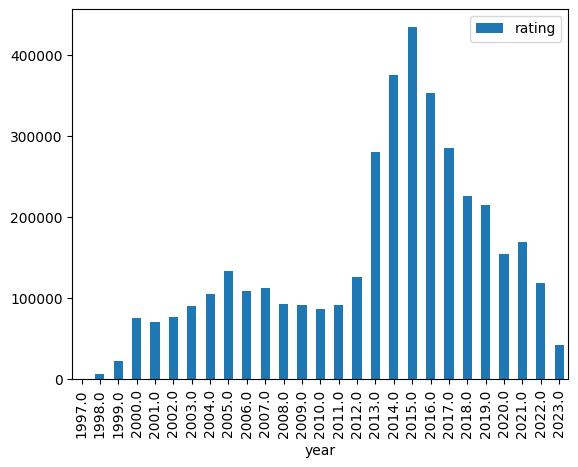

In [31]:
merge_df3.groupby('year').agg({'rating':'count'}).reset_index().plot(x='year',kind='bar')

In [32]:
merge_df3['label'] = merge_df3['rating'].apply(lambda x: 1 if x >= 5 else 0)
merge_df3['label'].describe()

/var/folders/1l/fxxxl8p13clcn13ph4b5wcjc0000gn/T/ipykernel_12972/3876990936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_df3['label'] = merge_df3['rating'].apply(lambda x: 1 if x >= 5 else 0)


count    3.939813e+06
mean     7.414078e-01
std      4.378611e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: label, dtype: float64

In [33]:
# creates mappings for user IDs and item IDs to consecutive numerical values, starting from 1
users = merge_df3.uid.unique()
items = merge_df3.iid.unique()
# creates dicts users_map, items_map where each unique uid, iid is mapped to a consecutive numerical value starting from 1
users_map = dict(zip(users, np.arange(users.shape[0])+1))
items_map = dict(zip(items, np.arange(items.shape[0])+1))

merge_df3['uid'] = merge_df3['uid'].map(users_map)
merge_df3['iid'] = merge_df3['iid'].map(items_map)
merge_df3.uid.max(), merge_df3.iid.max()

/var/folders/1l/fxxxl8p13clcn13ph4b5wcjc0000gn/T/ipykernel_12972/1523296764.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_df3['uid'] = merge_df3['uid'].map(users_map)
/var/folders/1l/fxxxl8p13clcn13ph4b5wcjc0000gn/T/ipykernel_12972/1523296764.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_df3['iid'] = merge_df3['iid'].map(items_map)


(np.int64(1559319), np.int64(258877))

In [34]:
merge_df3.head(3)

,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories,year,label
0,1.0,1,B000002X4C,1,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2015.0,0
1,1.0,1,B000002X4C,2,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2013.0,0
2,4.0,1,B000002X4C,3,9.534267e+11,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2000.0,0


In [35]:
merge_df3['time'] = ((pd.to_datetime(merge_df3['timestamp'], unit='ms') - date_min) // date_gap).astype(int)
merge_df3.head(5)

/var/folders/1l/fxxxl8p13clcn13ph4b5wcjc0000gn/T/ipykernel_12972/3529764540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merge_df3['time'] = ((pd.to_datetime(merge_df3['timestamp'], unit='ms') - date_min) // date_gap).astype(int)


,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories,year,label,time
0,1.0,1,B000002X4C,1,1.420266e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2015.0,0,34
1,1.0,1,B000002X4C,2,1.379363e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2013.0,0,32
2,4.0,1,B000002X4C,3,9.534267e+11,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2000.0,0,5
3,5.0,1,B000002X4C,4,1.427480e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2015.0,1,35
4,2.0,1,B000002X4C,5,1.289638e+12,Digital Music,Release Some Tension,4.6,112,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House",2010.0,0,26


In [36]:
#  splits the merge_df3 into train, val and test sets based on time
rating_train = merge_df3[merge_df3['time'].isin(range(2 * 26 - 2))].copy()
rating_valid_test = merge_df3[merge_df3['time'] == 2 * 26 - 2].copy()
rating_valid_test.sort_values(by='timestamp', inplace=True)
n = rating_valid_test.shape[0] // 2
rating_valid = rating_valid_test.iloc[:n].copy()
rating_test = rating_valid_test.iloc[n:].copy()
rating_train.shape, rating_valid.shape, rating_test.shape

((3865313, 14), (27559, 14), (27559, 14))

In [37]:
# identify cold-start, warm-start for val and test sets
# Adds a 'not_cold' column to rating_valid, marking interactions as 1 if both user and item exist in the training set, else 0
train_user = rating_train['uid'].unique()
train_item = rating_train['iid'].unique()
rating_valid['not_cold'] = rating_valid[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")
rating_test['not_cold'] = rating_test[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")

In [38]:
rating_train.shape, rating_valid.shape, rating_test.shape

((3865313, 14), (27559, 15), (27559, 15))

In [39]:
rating_valid.not_cold.value_counts(), rating_test.not_cold.value_counts()

(not_cold
 0    16416
 1    11143
 Name: count, dtype: int64,
 not_cold
 0    17661
 1     9898
 Name: count, dtype: int64)

In [40]:
# remove cold-start interactions from the validation and test sets
# cold-start interactions involve users or items that were not present in the training data
def filter_cold_start(train,valid,test):
    train_user = train.uid.unique()
    train_item = train.iid.unique()
    valid = valid[valid['uid'].isin(train_user)]
    test = test[test['uid'].isin(train_user)]
    valid = valid[valid['iid'].isin(train_item)]
    test = test[test['iid'].isin(train_item)]
    return valid, test

In [41]:
rating_train.label.mean(), rating_valid.label.mean(), rating_test.label.mean()

(np.float64(0.7410336497975714),
 np.float64(0.761493522987046),
 np.float64(0.7609492361841866))

In [42]:
# processes interaction data for each user
# creating a list of tuples representing each interaction along with the user's history
import copy

def deal_with_each_u(x,u):
    items = np.array(x.iid)
    labels = np.array(x.label)
    titles = np.array(x.title)
    descriptions = np.array(x.description)
    his = [0] # adding a '0' by default
    his_title = ['']
    his_description = ['']
    timestamp = np.array(x.timestamp)
    flags =  np.array(x.flag)
    his = [0] # adding a '0' by default
    his_title = ['']
    his_description = ['']
    results = []
    for i in range(items.shape[0]):
        results.append((u, items[i], timestamp[i], np.array(his), copy.copy(his_title), copy.copy(his_description), titles[i], descriptions[i], labels[i], flags[i]))
        # training data
        #  If the interaction is positive, the item ID and title are added to the user's history lists
        if labels[i] > 0: # positive
            his.append(items[i])
            his_title.append(titles[i])
            his_description.append(descriptions[i])
        # validation data
    return results

In [43]:
rating_valid_2 = rating_valid
rating_test_2 = rating_test

In [44]:
# adds a 'flag' column to the training, validation, and test sets
# assigns a value of -1 to all rows in this column, indicating that these rows belong to the training set
rating_train['flag'] =  pd.DataFrame(np.ones(rating_train.shape[0])*-1, index = rating_train.index) # 0 ~ valid set
rating_valid_2['flag'] = pd.DataFrame(np.zeros(rating_valid_2.shape[0]), index = rating_valid_2.index)  # 1 ~ test set
rating_test_2['flag'] = pd.DataFrame(np.ones(rating_test_2.shape[0]), index = rating_test_2.index)
data = pd.concat([rating_train, rating_valid_2, rating_test_2], axis = 0, ignore_index = True)
data = data.sort_values(by = ['uid','timestamp'])

# groups data df by user ID
# for each user group, it creates lists of item IDs ('iid'), labels, titles, description, timestamps, flags
u_inter_all = data.groupby('uid').agg({'iid':list, 'label':list, 'title':list, 'description': list, 'timestamp':list,'flag':list})


In [45]:
data.flag.unique()

array([-1.,  1.,  0.])

In [46]:
data.head(5)

,rating,iid,parent_iid,uid,timestamp,main_category,title,average_rating,rating_number,description,categories,year,label,time,flag,not_cold
1745972,3.0,105507,B001QCKJAM,1,1.372449e+12,Digital Music,Xscape: Super Hits,4.7,826,I will ship by EMS or SAL items in stock in Ja...,"CDs & Vinyl, Pop, Dance Pop",2013.0,0,31,-1.0,NaN
1725053,5.0,104264,B000063BQL,1,1.398165e+12,Digital Music,Ultimate Collection,4.8,406,Johnny Gill Collection gathers his best solo h...,"CDs & Vinyl, R&B, Soul",2014.0,1,33,-1.0,NaN
2636212,5.0,158563,B000001E3R,1,1.400653e+12,Digital Music,Natural Thing,4.7,40,,"CDs & Vinyl, R&B, Soul",2014.0,1,33,-1.0,NaN
562071,1.0,33735,B000251Y1C,1,1.413461e+12,Digital Music,Understanding,4.7,50,CD,"CDs & Vinyl, Pop, Dance Pop",2014.0,0,34,-1.0,NaN
2696883,5.0,162152,B0002Y4SUC,1,1.414292e+12,Digital Music,Soulful Sounds of Christmas,4.6,40,"Product Description, Get your holiday groove o...","CDs & Vinyl, Holiday & Wedding, Christmas",2014.0,1,34,-1.0,NaN


In [47]:
u_inter_all.head(5)

,iid,label,title,description,timestamp,flag
uid,,,,,,
1,"[105507, 104264, 158563, 33735, 162152, 218878...","[0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[Xscape: Super Hits, Ultimate Collection, Natu...",[I will ship by EMS or SAL items in stock in J...,"[1372448540000.0, 1398165102000.0, 14006530020...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...."
2,"[29336, 145546, 193637, 51321, 39017, 136295, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, ...","[Haunted, Mexican Moon, Ten, For Unlawful Carn...","[, NEW Combo BLUWAVS CD and FLAC FILE, Ten, th...","[1282765017000.0, 1300378226000.0, 13014264660...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...."
3,"[183331, 188977, 215841, 42910, 84909, 151378,...","[1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...","[1999, This Is Your Night, Design of a Decade ...","[Product Description, Certified at 4 million u...","[946548860000.0, 946556194000.0, 947984281000....","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...."
4,"[215837, 109106, 45788, 154345, 202017, 163705...","[1, 1, 1, 1, 1, 1, 1, 1, 1]","[Piece of Mind Explicit Lyrics, Shabba R...","[, , This product is an authorized manufacture...","[1356674276000.0, 1358400582000.0, 13584006580...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...."
5,"[214398, 53092, 81218, 197264, 124305, 33683, ...","[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, ...","[Charmbracelet, The Soul Sessions, Javier, The...","[Product description, A1, Amazon.com, Mariah C...","[1057855934000.0, 1066771811000.0, 10691320250...","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...."


In [ ]:
# each user in the u_inter_all df  
# apply the deal_with_each_u function to process their interaction data
# retrieves the row corresponding to the current uid and uid then add it to results
results = []
for u in u_inter_all.index:
    results.extend(deal_with_each_u(u_inter_all.loc[u], u))

In [51]:
len(results)

3920431

In [49]:
u, i, time, label, his, his_title, his_description, title, description, flag = [], [], [], [], [], [], [], [], [], []
for re in results:
    u.append(re[0])
    i.append(re[1])
    time.append(re[2])
    his.append(re[3])
    his_title.append(re[4])
    his_description.append(re[5])
    title.append(re[6])
    description.append(re[7])
    label.append(re[8])
    flag.append(re[9])

In [54]:
data = pd.DataFrame({"uid": u,'iid': i,'label': label, 'timestamp': time, 'his': his,'his_title': his_title, 'his_description': his_description, 'title': title, 'description': description, 'flag': flag})


In [55]:
data.head(5)

,uid,iid,label,timestamp,his,his_title,his_description,title,description,flag
0,1,105507,0,1.372449e+12,[0],[],[],Xscape: Super Hits,I will ship by EMS or SAL items in stock in Ja...,-1.0
1,1,104264,1,1.398165e+12,[0],[],[],Ultimate Collection,Johnny Gill Collection gathers his best solo h...,-1.0
2,1,158563,1,1.400653e+12,"[0, 104264]","[, Ultimate Collection]","[, Johnny Gill Collection gathers his best sol...",Natural Thing,,-1.0
3,1,33735,0,1.413461e+12,"[0, 104264, 158563]","[, Ultimate Collection, Natural Thing]","[, Johnny Gill Collection gathers his best sol...",Understanding,CD,-1.0
4,1,162152,1,1.414292e+12,"[0, 104264, 158563]","[, Ultimate Collection, Natural Thing]","[, Johnny Gill Collection gathers his best sol...",Soulful Sounds of Christmas,"Product Description, Get your holiday groove o...",-1.0


In [56]:
data.tail(5)

,uid,iid,label,timestamp,his,his_title,his_description,title,description,flag
3920426,1559315,258872,1,1.572986e+12,[0],[],[],My Love Is Your Love,,-1.0
3920427,1559316,258874,1,1.537987e+12,[0],[],[],Streets of Gold explicit_lyrics,International pressing includes one bonus trac...,-1.0
3920428,1559317,258875,1,1.525041e+12,[0],[],[],EXO-K Mama 1st Mini Album CD Korean Language K...,EXO-K Mama 1st Mini Album CD Korean Language K...,-1.0
3920429,1559318,258875,1,1.447653e+12,[0],[],[],EXO-K Mama 1st Mini Album CD Korean Language K...,EXO-K Mama 1st Mini Album CD Korean Language K...,-1.0
3920430,1559319,258875,0,1.515795e+12,[0],[],[],EXO-K Mama 1st Mini Album CD Korean Language K...,EXO-K Mama 1st Mini Album CD Korean Language K...,-1.0


In [57]:
data.label.describe()

count    3.920431e+06
mean     7.413175e-01
std      4.379109e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: label, dtype: float64

In [58]:
train = data[data['flag'].isin([-1])].copy()
val = data[data['flag'].isin([0])].copy()
test = data[data['flag'].isin([1])].copy()
train.shape,val.shape,test.shape

((3865313, 10), (27559, 10), (27559, 10))

In [59]:
train_user = train['uid'].unique()
train_item = train['iid'].unique()
val['not_cold'] = val[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")
test['not_cold'] = test[['uid','iid']].apply(lambda x: x.uid in train_user and x.iid in train_item, axis=1).astype("int")

In [60]:
train['not_cold'] = pd.DataFrame(np.ones(train.shape[0]), index = train.index).astype("int")
train.head(2)

,uid,iid,label,timestamp,his,his_title,his_description,title,description,flag,not_cold
0,1,105507,0,1.372449e+12,[0],[],[],Xscape: Super Hits,I will ship by EMS or SAL items in stock in Ja...,-1.0,1
1,1,104264,1,1.398165e+12,[0],[],[],Ultimate Collection,Johnny Gill Collection gathers his best solo h...,-1.0,1


In [ ]:
train.shape, val.shape, test.shape

In [66]:
# save
save_path = "../../data/amazon"
train.to_pickle(save_path + "train_amazon.pkl")
val.to_pickle(save_path + "valid_amazon.pkl")
test.to_pickle(save_path + "test_amazon.pkl")

: 

In [ ]:
# merge df vs meta
merged_df = user_df.merge(meta_df, on='parent_asin', how='right', suffixes=('', '_meta'))
merged_df = merged_df.rename(columns={'title': 'title_review'})
merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], unit='s')
merged_df

,rating,title_review,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_meta,average_rating,rating_number,features,description,categories,details
0,1.0,Weak,Definitely the weakest of the three albums SWV...,B000002X4C,B000002X4C,AGDQO4VIXXMHZMFRFHAHO2PNCYRQ,2015-01-03 06:22:17.000,1.0,0.0,Release Some Tension,4.6,112,,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
1,1.0,Too Many Guest Spots,Unlike It's About Time and New Beginning this ...,B000002X4C,B000002X4C,AEYOPYIIRMWVY5BLNZKZFZFJFQRA,2013-09-16 20:19:59.000,1.0,1.0,Release Some Tension,4.6,112,,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
2,4.0,"When &quot;Tension&quot; is released, expect q...","Their third and final album as a group, &quot;...",B000002X4C,B000002X4C,AHAIZWWINONHYU7A3FVCEH75R4CA,2000-03-19 00:44:40.000,1.0,0.0,Release Some Tension,4.6,112,,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
3,5.0,Thanks,thank you,B000002X4C,B000002X4C,AE73R3KLFKXFNWUBOA4JCLT5UWKA,2015-03-27 18:15:21.000,0.0,1.0,Release Some Tension,4.6,112,,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
4,2.0,Release Some Tension - 2.5 stars,When I was trying to decide whether or not to ...,B000002X4C,B000002X4C,AFICHVZ62IFAWIBZK3U6B7NZWAVQ,2010-11-13 08:44:58.000,3.0,0.0,Release Some Tension,4.6,112,,Swv ~ Release Some Tension,"CDs & Vinyl, Dance & Electronic, House","{""Is Discontinued By Manufacturer"": ""No"", ""Pro..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4827554,5.0,A Singer of Distinction,"Dame Joan Hilda Hood Hammond, DBE, CMG (24 May...",B000T001IM,B000T001IM,AFICGLJ62Y3YRTYN7PNYM6UUOA6Q,2013-12-20 11:54:02.000,1.0,1.0,"Joan Hammond, Historical Recordings from 1941-49",5.0,1,,,"CDs & Vinyl, Classical",{}
4827555,4.0,Great Performer!,I first saw Heinz Winckler in a Broadway music...,B00069I6RO,B00069I6RO,AHLRFMDIVAQF7ARTPM6PVJO6DTYQ,2008-01-03 08:10:12.000,2.0,1.0,Come Alive,4.5,4,,The Second Full Length Album from the Winner o...,"CDs & Vinyl, International Music, Africa, Sout...","{""Package Dimensions"": ""5.55 x 4.97 x 0.54 inc..."
4827556,5.0,Cheaper,"OK, loves, it's cheaper to go to amazon.co.uk ...",B00069I6RO,B00069I6RO,AGZVQUGBE64F3M2A5EBU2CNDTKIA,2004-12-15 22:34:52.000,5.0,0.0,Come Alive,4.5,4,,The Second Full Length Album from the Winner o...,"CDs & Vinyl, International Music, Africa, Sout...","{""Package Dimensions"": ""5.55 x 4.97 x 0.54 inc..."
4827557,5.0,Beautiful and poignant.,Wonderful collection of songs with haunting tu...,B08BF2PH1X,B08BF2PH1X,AEZET6CFIEJWTU7UTEK57IDARX2A,2021-02-09 22:59:55.740,0.0,1.0,Long Day in the Milky Way,4.4,16,,2020 release from the folk/Americana singer/so...,"CDs & Vinyl, Folk","{""Product Dimensions"": ""5.5 x 4.9 x 0.4 inches..."


In [ ]:
# filter merge_df with rating >= 3
merged_df['like'] = merged_df['rating']>3

# data.drop_duplicates(subset=['asin'])

In [ ]:
# encode user_id and asin
merged_df['user_id_encoded'] = LabelEncoder().fit_transform(merged_df['user_id'])
merged_df['asin_encoded'] = LabelEncoder().fit_transform(merged_df['asin'])
merged_df['parent_asin_encoded'] = LabelEncoder().fit_transform(merged_df['parent_asin'])

# data partition
# merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)
df_train, df_test = train_test_split(merged_df, test_size=0.2, random_state=42)
train_interactions_set = set(zip(df_train['user_id_encoded'], df_train['asin_encoded']))
df_test = df_test[~df_test[['user_id_encoded', 'asin_encoded']].apply(tuple, axis=1).isin(train_interactions_set)]

## Lightfm

In [ ]:
dataset = Dataset()
dataset.fit(users= merged_df['user_id_encoded'], items = merged_df['asin_encoded'])
train_interactions, train_w = dataset.build_interactions((row['user_id_encoded'], row['asin_encoded']) for id, row in df_train.iterrows())
test_interactions, test_w = dataset.build_interactions((row['user_id_encoded'], row['asin_encoded']) for id, row in df_test.iterrows())

In [ ]:
model = LightFM(loss='warp', item_alpha=1e-6, user_alpha=1e-6)
# train model
model.fit(train_interactions, epochs=50, num_threads=2, sample_weight=train_w)

In [ ]:
def add_combined_text(row):
    combined_text = f"title_review: {str(row['title_review'])}, text: {str(row['text'])}, title_meta: {str(row['title_meta'])}, features: {str(row['features'])}, description: {str(row['description'])}, details: {str(row['details'])}, categories: {str(row['categories'])}"
    row['combined_text'] = combined_text
    return row

# data = merged_df.map(add_combined_text)
merged_df = merged_df.apply(add_combined_text, axis=1)
# combined_texts = merged_df["combined_text"]
merged_df

,rating,title_review,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,title_meta,...,rating_number,features,description,categories,details,like,user_id_encoded,asin_encoded,parent_asin_encoded,combined_text
0,3.0,Three Stars,all advertizements,B00FA7T630,B00FA7T630,AFNRZBYAPLFKJNJU5BK3TTRWHJ6A,2015-10-26 17:49:26.000,0,1,GQ Print Access Print Magazine,...,10,,"Product Description, Dive into, GQ, ’s culture...",,"{""Date First Available"": ""June 2, 2020"", ""Manu...",False,24328,2499,2499,"title_review: Three Stars, text: all advertize..."
1,5.0,A great audiophile audio magazine that covers ...,A great audiophile audio magazine that covers ...,B00F8P62PO,B00F8P62PO,AETSCPCEEZ3S3BGNU4WCIN4H62ZQ,2018-01-11 07:17:33.014,6,1,Hi-Fi + Print Magazine,...,44,,Hi-Fi+ is Europe's premier English-language hi...,"Magazine Subscriptions, Arts, Music & Photogra...","{""Date First Available"": ""September 19, 2013"",...",True,12133,2498,2498,title_review: A great audiophile audio magazin...
2,3.0,inspirational,i really like the ideas they have in this maga...,B003F1W9T6,B003F1W9T6,AGQCHHMSO6S2DJLWGGFLCVUY477Q,2011-12-24 03:36:48.000,2,1,Paper Crafts,...,3,,,,"{""Date First Available"": ""May 12, 2021""}",False,40505,2095,2095,"title_review: inspirational, text: i really li..."
3,2.0,Should be called card making,"I ordered this magazine because I enjoy ""paper...",B003F1W9T6,B003F1W9T6,AEIKS6KU32T7VBIAP7YIMR2LICQQ,2013-03-03 05:28:59.000,0,1,Paper Crafts,...,3,,,,"{""Date First Available"": ""May 12, 2021""}",False,6799,2095,2095,"title_review: Should be called card making, te..."
4,4.0,Four Stars,Son loves this,B00007AXX1,B00007AXX1,AGDDHCNIGZPKBQRST6UVTCVPD53A,2015-12-04 12:24:30.000,0,1,Horse Illustrated,...,284,,,"Magazine Subscriptions, Sports, Recreation & O...","{""Package Dimensions"": ""10.79 x 8.11 x 0.31 in...",True,34411,871,871,"title_review: Four Stars, text: Son loves this..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71492,1.0,"Beautiful fashion magazine, subscription never...",I have been subscribing to V for a few years n...,B0007INIGI,B0007INIGI,AFDU3G7WMDWWA2XJLYNQLHSIEZMQ,2012-03-01 16:47:32.000,1,1,V Magazine - Ny Print Magazine,...,5,,"V Magazine, was launched in September 1999 as ...","Magazine Subscriptions, Fashion & Style, Men","{""Date First Available"": ""September 14, 2006"",...",False,19700,1315,1315,"title_review: Beautiful fashion magazine, subs..."
71493,1.0,What a fiasco,I subscribed to this magazine a year ago and n...,B0002800W8,B0002800W8,AG5BWPCEIS6FEJKQZTLJVQLGQNGA,2007-09-05 15:08:34.000,2,0,Victorian Review Print Magazine,...,1,,"Published since 1972,, Victorian Review, is an...",,"{""Date First Available"": ""September 14, 2006"",...",False,31564,1248,1248,"title_review: What a fiasco, text: I subscribe..."
71494,1.0,Have yet to receive the first issue,It has been a month since I purchased this mag...,B00007L0RC,B00007L0RC,AHA6K63RE5ODXSTDNPRND73U3EMQ,2011-02-15 16:55:54.000,0,1,Visto Print Magazine,...,2,,"A news magazine targeted at the wider public, ...",,"{""Date First Available"": ""September 15, 2013"",...",False,47920,1032,1032,title_review: Have yet to receive the first is...
71495,4.0,Super Fast Delivery,I was totally surprised how fast I received th...,B00007L0RC,B00007L0RC,AGQT3FF5NHZUOS3YSEAMIRY65VRQ,2012-01-18 22:58:43.000,0,1,Visto Print Magazine,...,2,,"A news magazine targeted at the wider public, ...",,"{""Date First Available"": ""September 15, 2013"",...",True,40744,1032,1032,"title_review: Super Fast Delivery, text: I was..."


In [ ]:
def get_purchase_history(merged_df, user_id, k):
    user_hist = merged_df[merged_df['user_id_encoded']==user_id]
    user_hist_sorted = user_hist.sort_values(by='timestamp', ascending=False)
    recent_purchase = user_hist_sorted[['asin', 'title_meta', 'description', 'combined_text']].head(k)
    return recent_purchase

def get_like_items(merged_df, user_id):
    like_items = merged_df[(merged_df['user_id_encoded']==user_id) & (merged_df['like']==True)].sort_values(by='timestamp', ascending=False)
    like_items = like_items[['asin', 'title_meta', 'description']].iloc[:10]
    return like_items

def get_dislike_items(merged_df, user_id):
    dislike_items = merged_df[(merged_df['user_id_encoded']==user_id) & (merged_df['like']==False)].sort_values(by='timestamp', ascending=False)
    dislike_items = dislike_items[['asin', 'title_meta', 'description']].iloc[:10]
    return like_items

In [ ]:
def evaluate_recall(model, train_interactions, test_interactions, k):
    precision= precision_at_k(model, test_interactions, train_interactions=train_interactions, k=k).mean()
    recall= recall_at_k(model, test_interactions, train_interactions=train_interactions, k=k).mean()
    auc= auc_score(model, test_interactions, train_interactions=train_interactions).mean()
    return precision, recall, auc

eval_metrics = evaluate_recall(model, train_interactions, test_interactions, k=50)

In [ ]:
print(eval_metrics)

(0.010412165, 0.20115773521154753, 0.85380054)


In [ ]:
def get_top_k(model, dataset, merged_df, user_id, k):
    n_users, n_items = dataset.interactions_shape()

    user_ids = np.full(n_items, user_id)  # or use np.repeat(user_id, n_items)
    # item_ids = np.arange(n_items)
    interacted_items = set(merged_df[merged_df['user_id_encoded']==user_id]['asin_encoded'])

    scores = model.predict(user_ids, np.arange(n_items))
    scores[list(interacted_items)] = -np.inf

    top_items_encoded = np.argsort(-scores)[:k]
    asin_info = dict(zip(merged_df['asin_encoded'], zip(merged_df['asin'], merged_df['title_meta'], merged_df['combined_text'])))
    recs = [asin_info[item] for item in top_items_encoded if item in asin_info]
    return recs

# user_id_encoder = dict(zip(merged_df['user_id_encoded'], merged_df['user_id']))
recs_dict = {user_id: get_top_k(model, dataset, merged_df, user_id, k=50) for user_id in merged_df['user_id_encoded'].unique()}

def get_recs(user_id):
    return recs_dict.get(user_id, [])

In [ ]:
user_id_test = merged_df['user_id_encoded'].iloc[8]
recent_purchases = get_purchase_history(merged_df, user_id_test, k=10)
like_items = get_like_items(merged_df, user_id_test)
dislike_items = get_dislike_items(merged_df, user_id_test)
top_k_recs= get_recs(user_id_test)

In [ ]:
top_k_recs

[('B00007B1JS',
  'Soap Opera Digest',
  'title_review: Subscription, text: I am unable to review this magazine  I have never received an issue.<br /><br />Needless to say, I am not happy about this.<br /><br />Lynda Epler, title_meta: Soap Opera Digest, features: , description: , details: {"Date First Available": "April 30, 2015"}, categories: Magazine Subscriptions, Entertainment & Pop Culture, Television'),
 ('B00GBJIEQG',
  'Inked',
  'title_review: Five Stars, text: Great magazine, title_meta: Inked, features: , description: , details: {"Date First Available": "October 31, 2013"}, categories: Magazine Subscriptions, Professional & Educational Journals, Professional & Trade, Arts, Photography'),
 ('B00007EN1O',
  'Alpaca    Print Magazine',
  'title_review: Excellent publication about alpacas, text: This magazine is a must for any alpaca owner, would be alpaca owner, or one who is just learning about these beautiful animals.<br />It is beautifully done, showing pictures of alpacas,

In [ ]:
user_id_test = merged_df['user_id_encoded'].iloc[8]
recent_purchases = get_purchase_history(merged_df, user_id_test, k=3)
recent_purchases

,asin,title_meta,description,combined_text
8,B00007AXX1,Horse Illustrated,,"title_review: Great Magazine, text: This magaz..."


In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 6.6 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoModel, AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain.document_loaders import TextLoader
from langchain.vectorstores import Chroma
from langchain.prompts import PromptTemplate
from langchain.embeddings import HuggingFaceEmbeddings
from langchain_huggingface.llms import HuggingFacePipeline
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document
from langchain.chains import RetrievalQA

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:

# since max number of tokens of sentence transformers is 512
# split the text into smaller chunks that fit within this limit before embedding
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

# prepare documents
def prepare_documents(user_id_test, recs):
    documents = []
    for asin, title_meta, combined_text in recs:
        chunks = text_splitter.split_text(combined_text)
        for chunk in chunks:
            metadata = {
                "asin": asin,
                "title_meta": title_meta,
            }
            doc = Document(page_content=chunk, metadata=metadata)
            documents.append(doc)
    return documents

user_documents = prepare_documents(user_id_test, top_k_recs)
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = "YOUR_HUGGINGFACE_TOKEN_HERE"
# YOUR_HUGGINGFACE_TOKEN_HERE
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-mpnet-base-v2')
chroma_client = Chroma.from_documents(documents=user_documents, embedding=embeddings, persist_directory="./content/chroma_db")

def get_search_result(user_query, chroma_client, k):
    res = chroma_client.similarity_search(query=user_query, k=k)
    return res



<ipython-input-25-0d67646e6ac0>:22: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-mpnet-base-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
user_query= "beauty magazine that can provide beauty tips"
retrieved_docs = get_search_result(user_query, chroma_client, k=5)
retrieved_docs

[Document(metadata={'asin': 'B00005QJE2', 'title_meta': 'Nylon    Print Magazine'}, page_content='interested in a fashion magazine that goes beyond a "beach read.", title_meta: Nylon    Print Magazine, features: , description: A vibrant and proactive voice for today\'s hip, intelligent, young women seeking fresh perspectives on fashion, beauty and music., details: {"Date First Available": "September 14, 2006", "Manufacturer": "Nylon Media Inc."}, categories: Magazine Subscriptions, Business & Investing, International'),
 Document(metadata={'asin': 'B00005QJE2', 'title_meta': 'Nylon    Print Magazine'}, page_content='title_review: inspiring, text: as a high school student aspiring to attend art school, nylon has provided me with countless sources of inspiration in their creative photography, layout, and decoration. i look forward to reading the magazine each month, and i honestly devour every last word and picture.<br /><br />nylon is a creative, whimsical and fantastic magazine. i high

In [ ]:
# !pip install accelerate

In [ ]:
model_id = "nvidia/Mistral-NeMo-Minitron-8B-Base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
# dtype = torch.bfloat16
model = AutoModelForCausalLM.from_pretrained(model_id, load_in_8bit=True)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=100,
)

# HuggingFace pipeline integration
hf = HuggingFacePipeline(pipeline=pipe)
llm = hf

tokenizer_config.json:   0%|          | 0.00/177k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
`low_cpu_mem_usage` was None, now default to True since model is quantized.


...

model-00002-of-00004.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

In [ ]:
prompt_template = """
Imagine you are a recommender. Given the user's recent purchase history, liked items, disliked items, and query:
User Query: {question}
Recent Purchases: {purchase_history}
Liked Items: {liked_items}
Disliked Items: {disliked_items}

Please rank the following items based on relevance and provide a brief explanation for each:
{context}
Reranked Recommendations:
"""

def personal_rerank(user_query, recent_purchase, retrieved_docs, like_items, dislike_items, llm, prompt_template):
    purchase_hist = "\n".join([f"{i+1}. {row['title_meta']}: {row['description']}" for i, (_, row) in enumerate(recent_purchases.iterrows())])
    context = "\n".join(f"{doc.metadata['title_meta']}: {doc.page_content}" for doc in retrieved_docs)
    prompt = prompt_template.format(
        question=user_query,
        purchase_history=purchase_hist,
        liked_items="\n".join(like_items),
        disliked_items="\n".join(dislike_items),
        context=context
    )
    return llm(prompt)


In [ ]:
user_query = "beauty magazine that can provide beauty tips"
retrieved_docs = get_search_result(user_query, chroma_client, k=5)
